# 层次聚类轨迹单元：二维降维可视化（UMAP / t-SNE / PCA）

读取 `output/time_series_hierarchical/trajectory_units_dimred_2d_hier_dtw.csv`，在三种二维坐标上展示 **(国家, 主题)** 轨迹单元；

- **颜色**：`trajectory_cluster`（层次聚类得到的轨迹类别）。
- **符号强调**：**中国 (`CN`)** 使用 **星形 (`*`)**；**美国 (`US`)** 使用 **加号形 (`P`，matplotlib 的 filled plus）**，并在散点上保留描边以便与普通圆点区分。

**运行前提**：在仓库根目录启动 Jupyter（当前工作目录为项目根），以便相对路径可用。

**按主题筛选 2D 图**：在首个代码单元中设置 `SELECT_TOPIC`：`None` 表示全部主题；设为整数主题编号（如 `5`）则仅展示该主题下各国轨迹单元。


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# 关键配置：设置字体为黑体，并正常显示负号
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac自带支持中文
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

REPO_ROOT = Path.cwd()
DATA_PATH = REPO_ROOT / "output/time_series_hierarchical/trajectory_units_dimred_2d_hier_dtw.csv"

df = pd.read_csv(DATA_PATH)
_need = {
    "country",
    "topic",
    "trajectory_cluster",
    "umap_1",
    "umap_2",
    "tsne_1",
    "tsne_2",
    "pca_1",
    "pca_2",
}
missing = sorted(_need.difference(df.columns))
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

HIGHLIGHT_CN = "CN"
HIGHLIGHT_US = "US"

df["trajectory_cluster"] = df["trajectory_cluster"].astype(int)
df["topic"] = df["topic"].astype(int)
clusters = sorted(df["trajectory_cluster"].unique())
cmap = plt.get_cmap("tab10")
cluster_colors = {c: cmap(i % 10) for i, c in enumerate(clusters)}

# None: all topics; int: single topic id present in CSV `topic` column
SELECT_TOPIC: int | None = None

print("rows:", len(df))
print("trajectory_cluster counts:")
print(df["trajectory_cluster"].value_counts().sort_index().to_string())
print("CN rows:", int((df["country"] == HIGHLIGHT_CN).sum()), "US rows:", int((df["country"] == HIGHLIGHT_US).sum()))
print("unique topics:", len(df["topic"].unique()), "min/max:", int(df["topic"].min()), int(df["topic"].max()))


rows: 662
trajectory_cluster counts:
trajectory_cluster
0    121
1    499
2      5
3     37
CN rows: 49 US rows: 49


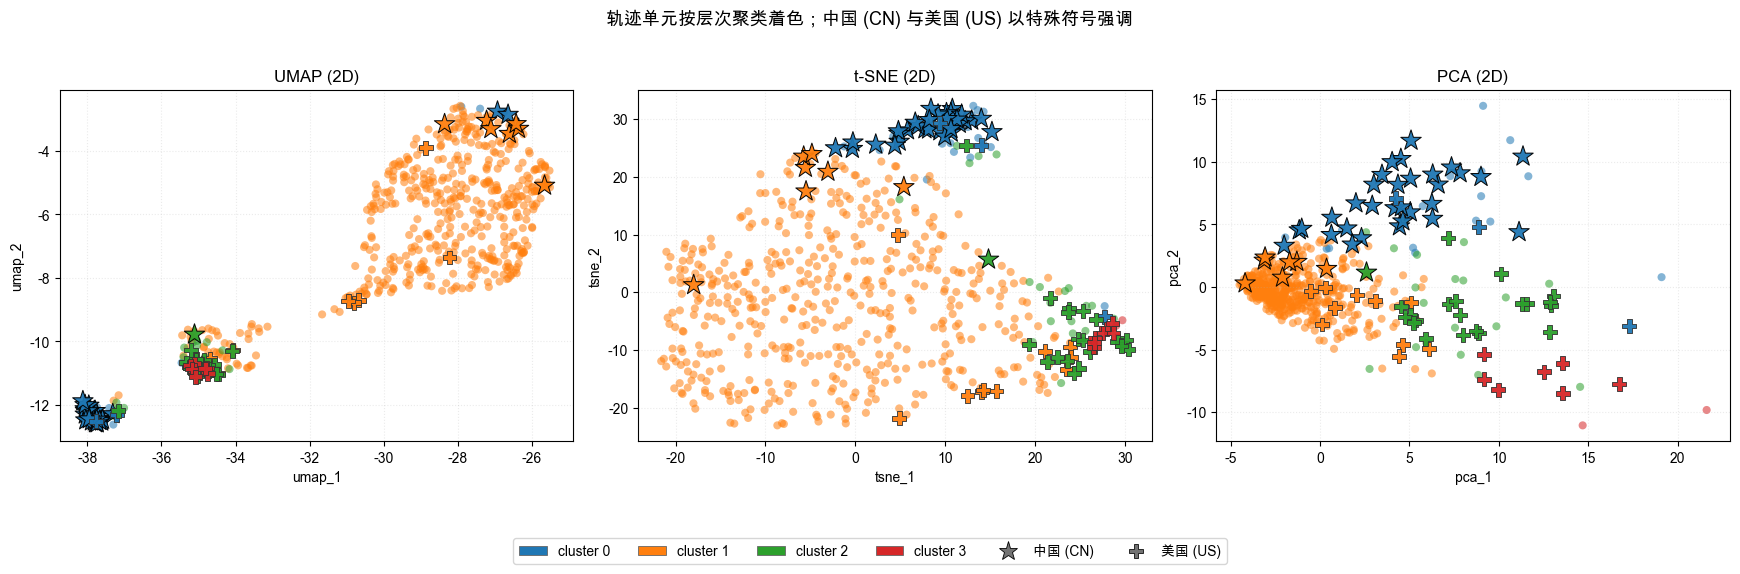

In [2]:
def plot_embedding_panel(
    ax: plt.Axes,
    frame: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    clusters: list[int],
    cluster_colors: dict[int, tuple],
) -> None:
    # Base scatter: non-highlight countries as disks; CN/US drawn again on top with special markers.
    others = frame[~frame["country"].isin([HIGHLIGHT_CN, HIGHLIGHT_US])]
    cn = frame[frame["country"] == HIGHLIGHT_CN]
    us = frame[frame["country"] == HIGHLIGHT_US]

    for c in clusters:
        color = cluster_colors[c]
        sub = others[others["trajectory_cluster"] == c]
        ax.scatter(
            sub[x_col],
            sub[y_col],
            c=[color] * len(sub),
            marker="o",
            s=34,
            alpha=0.55,
            edgecolors="none",
        )
        sub_cn = cn[cn["trajectory_cluster"] == c]
        if not sub_cn.empty:
            ax.scatter(
                sub_cn[x_col],
                sub_cn[y_col],
                c=[color] * len(sub_cn),
                marker="*",
                s=240,
                alpha=0.95,
                edgecolors="black",
                linewidths=0.75,
                zorder=5,
            )
        sub_us = us[us["trajectory_cluster"] == c]
        if not sub_us.empty:
            ax.scatter(
                sub_us[x_col],
                sub_us[y_col],
                c=[color] * len(sub_us),
                marker="P",
                s=100,
                alpha=0.95,
                edgecolors="0.2",
                linewidths=0.65,
                zorder=6,
            )

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.25, linestyle=":")


if SELECT_TOPIC is not None:
    _topics_avail = sorted(df["topic"].unique())
    if SELECT_TOPIC not in _topics_avail:
        raise ValueError(
            f"SELECT_TOPIC={SELECT_TOPIC} not in CSV; available topic ids: {_topics_avail}"
        )
    plot_df = df.loc[df["topic"] == SELECT_TOPIC].copy()
    if plot_df.empty:
        raise ValueError(f"No rows for topic {SELECT_TOPIC}")
    title_topic_suffix = f"（主题 {SELECT_TOPIC}）"
else:
    plot_df = df
    title_topic_suffix = ""

clusters_plot = sorted(plot_df["trajectory_cluster"].unique())

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.4))
plot_embedding_panel(axes[0], plot_df, "umap_1", "umap_2", "UMAP (2D)", clusters_plot, cluster_colors)
plot_embedding_panel(axes[1], plot_df, "tsne_1", "tsne_2", "t-SNE (2D)", clusters_plot, cluster_colors)
plot_embedding_panel(axes[2], plot_df, "pca_1", "pca_2", "PCA (2D)", clusters_plot, cluster_colors)

cluster_handles = [
    Patch(facecolor=cluster_colors[c], edgecolor="0.4", linewidth=0.6, label=f"cluster {c}")
    for c in clusters_plot
]
cn_legend = mlines.Line2D(
    [],
    [],
    color="0.45",
    marker="*",
    linestyle="None",
    markersize=14,
    markeredgecolor="black",
    markeredgewidth=0.6,
    label="中国 (CN)",
)
us_legend = mlines.Line2D(
    [],
    [],
    color="0.45",
    marker="P",
    linestyle="None",
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.55,
    label="美国 (US)",
)

fig.legend(
    handles=cluster_handles + [cn_legend, us_legend],
    loc="lower center",
    ncol=min(6, len(cluster_handles) + 2),
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(
    "轨迹单元按层次聚类着色；中国 (CN) 与美国 (US) 以特殊符号强调" + title_topic_suffix,
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()
